In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
#1. import database / data

In [3]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type = 'table';
"""

tables = pd.read_sql(sql_query, conn)

#create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df  
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [4]:
print(tables['name'].tolist())

['db_customer', 'db_subscription', 'db_support']


In [5]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable name: {table_name}")
    #Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns: ")
    print(columns['name'].tolist())

conn.close()


Table name: db_customer
Columns: 
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table name: db_subscription
Columns: 
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table name: db_support
Columns: 
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [6]:
#  2.Data cleaning

In [7]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [8]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
3016,9759-TNHXZ,karan,India,Haryana,Men,2010-12-16,sports,None
3017,0729-ACKEW,nisha,Nepal,Kathmandu,Female,1985-05-05,movie,None
3018,9143-EVDUJ,vikram,India,Nagaland,Male,1990-09-03,None,None
3019,0425-LVYDV,arjun,India,Karnataka,Male,1975-12-11,drama,None
3020,2949-MCZUQ,rahul,India,Punjab,Female,2007-05-21,movie,None


In [9]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3021 entries, 0 to 3020
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  3021 non-null   object
 1   name        3021 non-null   object
 2   country     2864 non-null   object
 3   state       3021 non-null   object
 4   gender      3021 non-null   object
 5   dob         3021 non-null   object
 6   interests   2566 non-null   object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 188.9+ KB


In [10]:
# a. rename col - name to customer_name
# b. drop columns - intersest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values (using existing data) - country
# f. Check duplicates, missing IDs, extra spaces
# g. Standardize spaces/capitalization

In [11]:
# a. rename col - name to customer_name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)

In [12]:
# b. drop columns - interest and pincode

df_db_customer.drop(columns = ['interests' , 'pincode'], inplace = True)

In [13]:
df_db_customer['dob'].apply(type).value_counts()

dob
<class 'str'>    3021
Name: count, dtype: int64

In [14]:
# c. change data type - dob


#df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

df_db_customer['dob'] = pd.to_datetime(
    df_db_customer['dob'],
    format='mixed',
    errors='coerce'
)

In [15]:
df_db_customer['dob'].head()

0   1982-04-12
1   1995-11-23
2   1978-02-15
3   2001-08-30
4   1990-05-05
Name: dob, dtype: datetime64[ns]

In [16]:
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men', 'male', 'women', 'female', 'men'],
      dtype=object)

In [17]:
# d. data standardization - gender
# Use .str.strip() --- for remove extra space

df_db_customer['gender'] = (
    df_db_customer['gender']
    .str.title()
    .replace({'Women':'Female', 'Men':'Male'})
)

In [18]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [19]:
# e. fix missing values (using existing data) - country

df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01
23,7363-TSUND,nisha,None,Kerala,Female,1998-08-02
26,4517-FCOXB,karan,None,Telangana,Male,1982-06-16
...,...,...,...,...,...,...
2927,0932-NZBLU,sanjay,None,Gujarat,Male,1991-12-31
2933,7547-NTIAU,meera,None,Telangana,Male,1991-10-01
2939,3280-DWGFH,karan,None,West Bengal,Female,2010-10-26
3001,6630-DDDHB,priya,None,Telangana,Female,1994-06-29


In [20]:
#country and state - unique value pair
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [21]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [22]:
#removing any extra space to avoid counting duplicate value

df_db_customer['country'] = df_db_customer['country'].str.strip()
df_db_customer['state'] = df_db_customer['state'].str.strip()

In [23]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
...,...,...
3016,India,Haryana
3017,Nepal,Kathmandu
3018,India,Nagaland
3019,India,Karnataka


In [24]:
#There is not any null value in Country and state so do not need this.

# indian_states = df_db_customer.loc[
#     df_db_customer['country'] == 'India', 'state'
# ].unique()

# df_db_customer.loc[
#     (df_db_customer['country'] != 'India') &
#     (df_db_customer['state'].isin(indian_states)),
#     'state'
# ] = np.nan

In [25]:
df_db_customer.groupby(['country', 'state'], dropna=False).size().reset_index(name='count')

,country,state,count
0,India,Delhi,216
1,India,Gujarat,199
2,India,Haryana,220
3,India,Karnataka,192
4,India,Kerala,202
5,India,Maharashtra,196
6,India,Meghalaya,216
7,India,Nagaland,207
8,India,Punjab,178
9,India,Rajasthan,210


In [26]:
# f. Check duplicates, missing IDs, extra spaces in customerid

df_db_customer[df_db_customer['customerid'].isna()]

,customerid,customer_name,country,state,gender,dob


In [27]:
df_db_customer[df_db_customer['customerid'].duplicated()]

,customerid,customer_name,country,state,gender,dob


In [28]:
df_db_customer[df_db_customer['customerid'] != df_db_customer['customerid'].str.strip()]

,customerid,customer_name,country,state,gender,dob


In [29]:
# g. Standardize spaces/capitalization

df_db_customer['customer_name'] = df_db_customer['customer_name'].str.title()

In [30]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,Keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,Raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,Lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,Mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,Mira,India,Delhi,Female,1990-05-05


In [31]:
# a. subscription_start_date - Convert to date;
# b. subscription_type	Standardize spelling, spaces
# c. renewal_date	Convert to date;
# d. plan_type	Standardize Basic, Standard, Premium; remove spaces/case inconsistencies
# e. contract_type	Standardize Monthly, Annual, etc.
# f. cancellation_date	Convert to date; NULL is legitimate for customers who haven't churned
# g. cancellation_reason	Standardize capitalization/spaces; NULL is legitimate for non-churned customers
# h. monthly_charges	Convert to numeric; investigate missing/invalid values
# i. cltv	Convert to numeric; investigate missing/invalid values

In [32]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627.0,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150.0,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210.0,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725.0,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195.0,88


In [33]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3021 entries, 0 to 3020
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               3021 non-null   object 
 1   subscription_start_date  3021 non-null   object 
 2   subscription_type        2977 non-null   object 
 3   renewal_date             3021 non-null   object 
 4   plan_type                2948 non-null   object 
 5   contract_type            2963 non-null   object 
 6   cancellation_date        1041 non-null   object 
 7   cancellation_reason      1041 non-null   object 
 8   monthly_charges          2972 non-null   float64
 9   cltv                     2954 non-null   float64
 10  churn_score              3021 non-null   int64  
dtypes: float64(2), int64(1), object(8)
memory usage: 259.7+ KB


In [34]:
# a. subscription_start_date - Convert to date;
# c. renewal_date	Convert to date;
# f. cancellation_date	Convert to date; 

date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3021 entries, 0 to 3020
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               3021 non-null   object        
 1   subscription_start_date  3021 non-null   datetime64[ns]
 2   subscription_type        2977 non-null   object        
 3   renewal_date             3021 non-null   datetime64[ns]
 4   plan_type                2948 non-null   object        
 5   contract_type            2963 non-null   object        
 6   cancellation_date        1041 non-null   datetime64[ns]
 7   cancellation_reason      1041 non-null   object        
 8   monthly_charges          2972 non-null   float64       
 9   cltv                     2954 non-null   float64       
 10  churn_score              3021 non-null   int64         
dtypes: datetime64[ns](3), float64(2), int64(1), object(5)
memory usage: 259.7+ KB


In [35]:
# b. subscription_type	Standardize spelling, spaces and capitalization

df_db_subscription['subscription_type'] = df_db_subscription['subscription_type'].str.strip()

In [36]:
df_db_subscription['subscription_type'] = df_db_subscription['subscription_type'].str.title()

In [37]:
# d. plan_type	Standardize Basic, Standard, Premium; remove spaces/case inconsistencies

df_db_subscription['plan_type'].unique()

array(['Standard', 'Premium', 'Basic', 'Standard ', ' Basic', 'PREMIUM',
       None], dtype=object)

In [38]:
df_db_subscription['plan_type'] = df_db_subscription['plan_type'].str.title().str.strip()

In [39]:
df_db_subscription['plan_type'].unique()

array(['Standard', 'Premium', 'Basic', None], dtype=object)

In [40]:
# e. contract_type	Standardize Monthly, Annual, etc.

df_db_subscription['plan_type'].unique()

array(['Standard', 'Premium', 'Basic', None], dtype=object)

In [41]:
df_db_subscription['contract_type'] = df_db_subscription['contract_type'].str.title().str.strip()

In [42]:
df_db_subscription['contract_type'].unique()

array(['Annual', 'Monthly', None], dtype=object)

In [43]:
# g. cancellation_reason	Standardize capitalization/spaces;

df_db_subscription['cancellation_reason'].unique()

array([None, 'Switched to competitor', 'Too expensive',
       'Not enough content', 'Poor streaming quality',
       'Forgot to cancel trial', 'Poor support', 'Poor Support',
       'Service quality'], dtype=object)

In [44]:
df_db_subscription['cancellation_reason'] = df_db_subscription['cancellation_reason'].str.title()

In [45]:
df_db_subscription['cancellation_reason'].unique()

array([None, 'Switched To Competitor', 'Too Expensive',
       'Not Enough Content', 'Poor Streaming Quality',
       'Forgot To Cancel Trial', 'Poor Support', 'Service Quality'],
      dtype=object)

In [46]:
# h. monthly_charges	Convert to numeric; investigate missing/invalid values

df_db_subscription[df_db_subscription['monthly_charges'].isnull()]

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
112,4305-PNRUK,2023-09-02,Paid,2024-09-01,Premium,None,NaT,None,NaN,1426.0,72
165,8464-SVVLB,2023-07-18,Organic,2023-08-17,Premium,Monthly,2025-06-22,Too Expensive,NaN,NaN,56
176,5386-SGQLY,2021-11-10,Refferal,2021-12-10,Basic,Monthly,NaT,None,NaN,251.0,45
196,5094-JNYBZ,2024-09-02,Organic,2024-10-02,None,Monthly,NaT,None,NaN,621.0,23
224,8095-LQOYR,2023-08-15,Organic,2023-09-14,Standard,Monthly,NaT,None,NaN,609.0,20
330,1088-WJPNT,2021-04-21,Organic,2022-04-21,None,Annual,NaT,None,NaN,616.0,83
364,3956-KXODS,2022-11-16,Organic,2023-11-16,Standard,Annual,NaT,None,NaN,389.0,6
431,3416-FMPMF,2022-09-08,Organic,2023-09-08,Premium,Annual,NaT,None,NaN,NaN,94
442,4696-YCOXU,2023-04-10,Paid,2023-05-10,Standard,Monthly,NaT,None,NaN,690.0,1
580,9751-LBWEN,2022-06-30,Organic,2022-07-30,None,Monthly,NaT,None,NaN,1017.0,52


In [47]:
df_db_subscription['monthly_charges'] = pd.to_numeric(
    df_db_subscription['monthly_charges'],
    errors='coerce'
)
#checking the data type
df_db_subscription['monthly_charges'].dtype

dtype('float64')

In [48]:
# i. cltv	Convert to numeric;

df_db_subscription[df_db_subscription['cltv'].isnull()]

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
36,4365-UVKXH,2025-04-26,Organic,2026-04-26,Standard,Annual,NaT,None,17.68,NaN,98
71,3651-VAXOD,2023-02-18,Paid,2023-03-20,Standard,Monthly,2026-02-05,Forgot To Cancel Trial,15.79,NaN,26
72,3038-OICRR,2026-03-31,Referral,2027-03-31,Basic,Annual,NaT,None,6.35,NaN,20
109,9153-XPEEH,2025-12-22,Organic,2026-01-21,Premium,Monthly,NaT,None,23.80,NaN,5
135,1713-UKPLU,2022-01-19,Referral,2022-02-18,Standard,Monthly,2024-04-24,Poor Support,13.51,NaN,100
...,...,...,...,...,...,...,...,...,...,...,...
2794,7682-LZAAO,2026-03-01,Paid,2026-03-31,Basic,Monthly,2026-05-07,Poor Support,5.52,NaN,84
2864,7300-GPQLA,2021-09-05,Organic,2022-09-05,Basic,Annual,NaT,None,8.59,NaN,80
2889,4631-RQKZF,2026-08-07,Refferal,2026-09-06,Basic,Monthly,NaT,None,7.49,NaN,97
2922,6996-IIMDK,2024-04-13,Referral,2024-05-13,Basic,Monthly,2024-05-17,Forgot To Cancel Trial,6.33,NaN,4


In [49]:
df_db_subscription['cltv'] = pd.to_numeric(
    df_db_subscription['cltv'],
    errors='coerce'
)
#checking the data type
df_db_subscription['cltv'].dtype

dtype('float64')

In [50]:
# a. complaint_date	Convert to date; check invalid dates
# b. col_1	Investigate what this column represents before using it

In [51]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [52]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4833 entries, 0 to 4832
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      4833 non-null   object
 1   complaint_date  4833 non-null   object
 2   escalations     4833 non-null   object
 3   csat_score      4833 non-null   int64 
 4   col_1           0 non-null      object
 5   comment         4215 non-null   object
dtypes: int64(1), object(5)
memory usage: 226.7+ KB


In [53]:
# b. col_1	Investigate what this column represents before using it - Drop this column

df_db_support.drop(columns = ['col_1','comment'], inplace = True)

In [54]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4833 entries, 0 to 4832
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      4833 non-null   object
 1   complaint_date  4833 non-null   object
 2   escalations     4833 non-null   object
 3   csat_score      4833 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 151.2+ KB


In [55]:
# a. complaint_date	Convert to date; check invalid dates

df_db_support['complaint_date'] = df_db_support['complaint_date'].apply(pd.to_datetime)

In [56]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4833 entries, 0 to 4832
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      4833 non-null   object        
 1   complaint_date  4833 non-null   datetime64[ns]
 2   escalations     4833 non-null   object        
 3   csat_score      4833 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 151.2+ KB


In [57]:
# 3. Feature Engineering & Data Analysis

In [58]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627.0,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched To Competitor,12.99,1150.0,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210.0,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725.0,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too Expensive,13.99,195.0,88


In [59]:
# create a new col using existing col - churn flag

# Customer is churned if cancellation_date is not null
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [60]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627.0,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched To Competitor,12.99,1150.0,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210.0,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725.0,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too Expensive,13.99,195.0,88,1


In [61]:
#4. Merge Dataframes - JOINs

In [62]:
#first fix support table duplicate then merge
df = (df_db_subscription
                .merge(df_db_customer, on='customerid', how='left')
                .merge(df_db_support, on='customerid', how='left'))

In [63]:
df_db_subscription.shape

(3021, 12)

In [64]:
df.shape

(5228, 20)

In [65]:
df_db_subscription['customerid'].nunique()

3021

In [66]:
df_db_customer['customerid'].nunique()

3021

In [67]:
df_db_support['customerid'].nunique()

2626

In [68]:
df_db_support['customerid'].size

4833

In [69]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
...,...,...,...,...
4828,8479-GSPXH,2025-08-24,N,84
4829,0266-HHLKW,2024-10-31,N,57
4830,8680-PJWZI,2023-08-31,Y,77
4831,5783-DLDOA,2023-09-27,N,60


In [70]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [71]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
...,...,...,...,...,...
4828,8479-GSPXH,2025-08-24,N,84,2
4829,0266-HHLKW,2024-10-31,N,57,3
4830,8680-PJWZI,2023-08-31,Y,77,3
4831,5783-DLDOA,2023-09-27,N,60,2


In [72]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [73]:
df_db_support['customerid'].size

2626

In [74]:
# merge df
df = (df_db_subscription
                .merge(df_db_customer, on='customerid', how='left')
                .merge(df_db_support, on='customerid', how='left'))

In [75]:
print("Rows:", len(df))
print("Unique customers:", df['customerid'].nunique())
print("Duplicate customer IDs:", df['customerid'].duplicated().sum())
print("Complaint count:", df['complaint_count'].sum())

Rows: 3021
Unique customers: 3021
Duplicate customer IDs: 0
Complaint count: 4833.0


In [76]:
df.shape

(3021, 21)

In [77]:
df.isnull().sum()

customerid                    0
subscription_start_date       0
subscription_type            44
renewal_date                  0
plan_type                    73
contract_type                58
cancellation_date          1980
cancellation_reason        1980
monthly_charges              49
cltv                         67
churn_score                   0
churn_flag                    0
customer_name                 0
country                       0
state                         0
gender                        0
dob                           0
complaint_date              395
escalations                 395
csat_score                  395
complaint_count             395
dtype: int64

In [78]:
df.to_csv('exported_churn_data.csv', index=False)

In [79]:
# 5. Data Analysis ***************

In [80]:
# 1.Churn Rate

In [81]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [82]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ",round(churn_rate,2),"%")

Churn Rate =  34.46 %


In [83]:
# 2. Retention Rate

retention_rate = 100 - churn_rate
print("Retention Rate = ",round(retention_rate,2),"%")

Retention Rate =  65.54 %


In [84]:
# 3.Churn by plan type

churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           38.98
1   Premium           28.15
2  Standard           34.33


In [85]:
df.columns.tolist()

['customerid',
 'subscription_start_date',
 'subscription_type',
 'renewal_date',
 'plan_type',
 'contract_type',
 'cancellation_date',
 'cancellation_reason',
 'monthly_charges',
 'cltv',
 'churn_score',
 'churn_flag',
 'customer_name',
 'country',
 'state',
 'gender',
 'dob',
 'complaint_date',
 'escalations',
 'csat_score',
 'complaint_count']

In [86]:
# 4 a. Churn by state + sum(revenue) & count of users
churn_by_state = df.groupby('state').agg(
    total_revenue=('monthly_charges', 'sum'),
    user_count=('customerid', 'count'),
    churn_rate=('churn_flag', 'mean')
).reset_index()

churn_by_state['churn_rate'] = (
    churn_by_state['churn_rate'] * 100
).round(2)

print(churn_by_state)

            state  total_revenue  user_count  churn_rate
0           Delhi        2973.91         216       29.17
1         Gujarat        2823.72         199       31.16
2         Haryana        2983.26         220       29.55
3       Karnataka        2499.79         192       40.62
4       Kathmandu        2510.77         174       35.06
5          Kerala        2664.34         202       33.66
6     Maharashtra        2591.16         196       32.14
7       Meghalaya        2882.66         216       37.96
8        Nagaland        2728.98         207       35.27
9          Punjab        2151.88         178       32.02
10      Rajasthan        2769.36         210       35.24
11     Tamil Nadu        2474.30         191       34.03
12      Telangana        2772.95         215       34.42
13  Uttar Pradesh        2684.68         195       40.51
14    West Bengal        2962.17         210       36.67


In [87]:
# 5.ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print("Avg Revenue per user = ",round(arpu,2))

Avg Revenue per user =  13.62


In [88]:
print(
    df.groupby('churn_flag')['monthly_charges']
      .agg(['count', 'mean', 'sum'])
)

            count       mean       sum
churn_flag                            
0            1951  13.948180  27212.90
1            1021  12.988276  13261.03


In [89]:
df.groupby('churn_flag')['monthly_charges'].agg(
    count='count',
    missing=lambda x: x.isna().sum(),
    mean='mean',
    sum='sum'
)

,count,missing,mean,sum
churn_flag,,,,
0,1951,29,13.948180,27212.90
1,1021,20,12.988276,13261.03


In [90]:
# 6. Avg Customer Tenure
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)
avg_tenure_days = df['tenure_days'].mean()
print("Avg Tenure days = ",round(avg_tenure_days))

Avg Tenure days =  883


In [91]:
# 7. Revenue at Risk - monthly revenue associated with churned users

Revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at risk per months (₹) = ", round(Revenue_at_risk,2))

Revenue at risk per months (₹) =  13261.03


In [92]:
# 8.1. Esclation Rate - Latest Support Escalation Rate

latest_escalation_rate = (
    (df['escalations'] == 'Y').mean() * 100
)
print(
    "Latest Support Escalation Rate =",
    round(latest_escalation_rate, 2),
    "%"
)

Latest Support Escalation Rate = 23.93 %


In [93]:
# 8.2. Total Escalation Rate - the percentage of support/complaint records that were escalated

print(df_db_support['escalations'].value_counts(dropna=False))

total_escalation_rate = (
    (df_db_support['escalations'] == 'Y').sum()
    / df_db_support['escalations'].notna().sum()
) * 100

print("Total Escalation Rate =", round(total_escalation_rate, 2), "%")

escalations
N    1903
Y     723
Name: count, dtype: int64
Total Escalation Rate = 27.53 %


In [94]:
df['complaint_count'].sum()

np.float64(4833.0)

In [95]:
df['customerid'].nunique()

3021

In [96]:
# 9. Avg Complaint Per User

avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaints Per User = ", round(avg_complaints,2))

Avg Complaints Per User =  1.6


In [97]:
# 10. Correlation Esclation vs Churn

df['escalations'] = np.where(df['escalations'] == 'Y',1,0) #encoding string to int type

In [98]:
corr_df = df[['escalations','churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  0.03


In [99]:
# 11. Create a column using existing col - Churn risk

conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]
choices = ['low','medium','high']
df['churn_risk'] = np.select(conditions, choices, default='unknown')

df[['churn_score','churn_risk']].head()

,churn_score,churn_risk
0,12,low
1,91,high
2,34,low
3,8,low
4,88,high


In [100]:
df = df.drop(columns=['csat_group'], errors='ignore')
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [101]:
# 4. Visualization using Matplotlib***********

In [102]:
# best practice to create a copy then work on it
df_visual = df.copy()

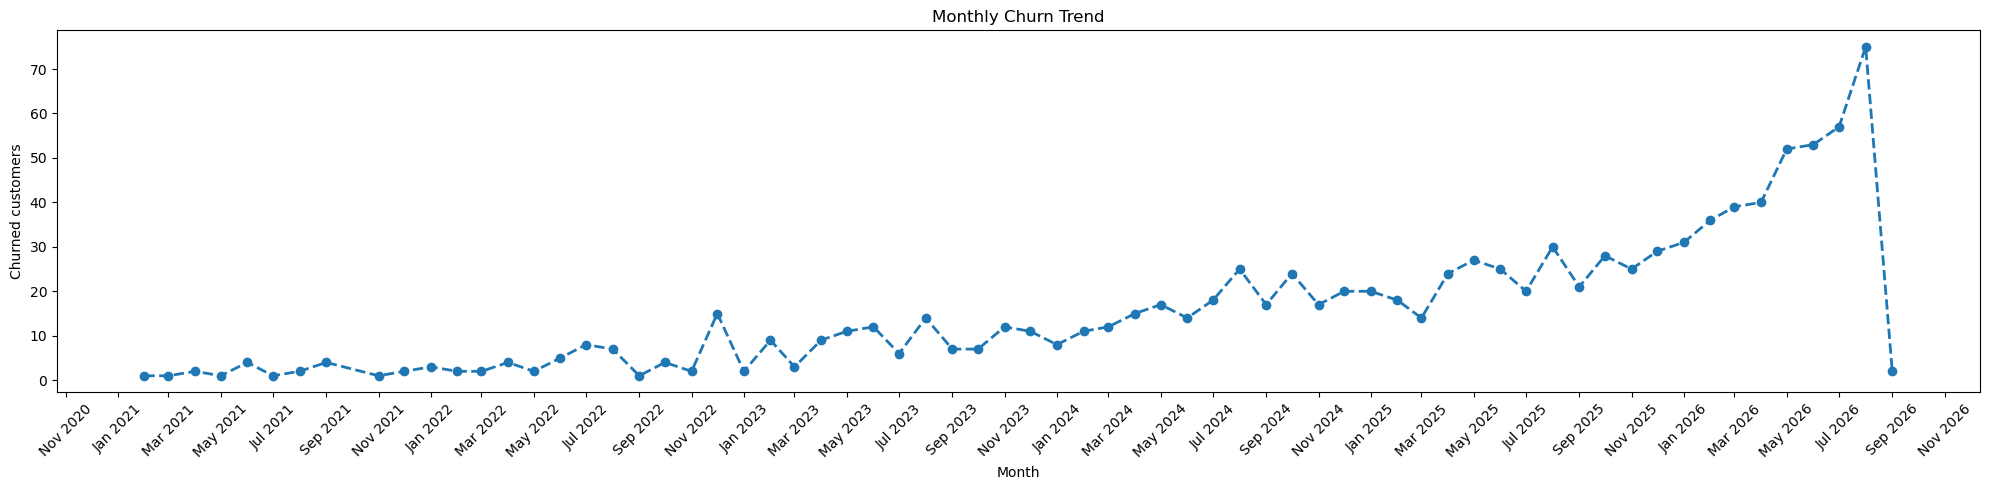

In [103]:
# 4.1 Monthly Churn Trend (Time Series KPI)

import matplotlib.dates as mdates

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = (
    df_visual[df_visual['churn_flag'] == 1]
    .groupby('cancellation_month')
    .size()
)

# Convert Period → datetime
churn_trend.index = churn_trend.index.to_timestamp()

plt.figure(figsize=(20, 5))
plt.plot(
    churn_trend.index,
    churn_trend.values,
    marker='o',
    linestyle='dashed',
    linewidth=2
)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned customers')

# Show one label every 2 months
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

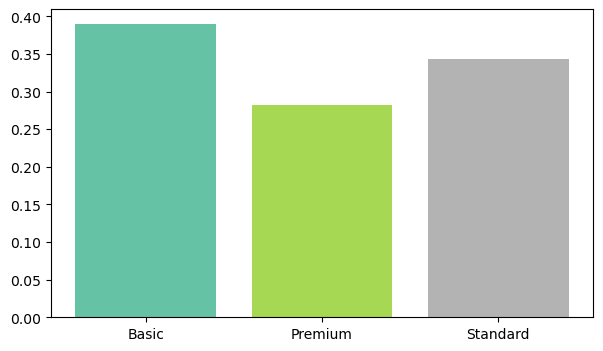

In [104]:
# 4.2 Churn by plan type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# Plot
#colors = ['red','green','blue'] --Manually
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

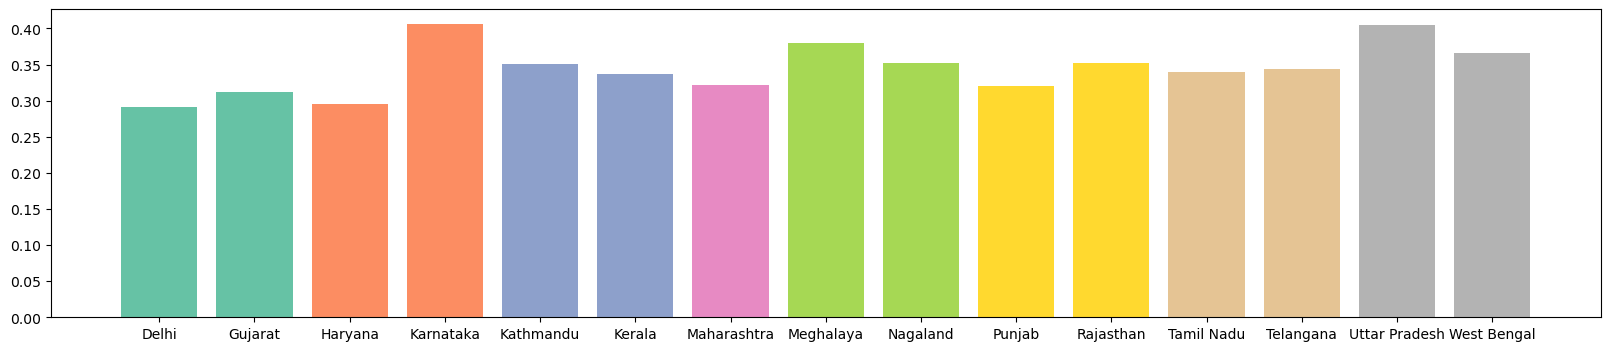

In [105]:
# 4.3 Churn by states

churn_plan = df_visual.groupby('state')['churn_flag'].mean()

# Plot
#colors = ['red','green','blue'] --Manually
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(20,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

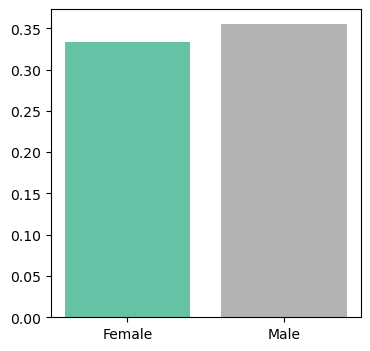

In [106]:
# 4.4 Churn by gender

churn_plan = df_visual.groupby('gender')['churn_flag'].mean()

# Plot
#colors = ['red','green','blue'] --Manually
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(4,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

In [107]:
# 4.5 Churn rate by contract type

contract_churn = (
    df.groupby('contract_type')['churn_flag']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(contract_churn)

contract_type
Monthly    38.688718
Annual     29.055118
Name: churn_flag, dtype: float64


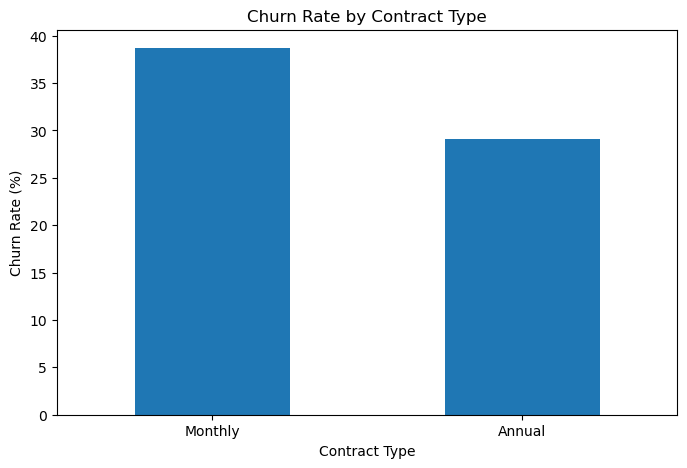

In [108]:
plt.figure(figsize=(8,5))

contract_churn.plot(kind='bar')

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [109]:
# 4.6 Churn rate by complaint count

complaint_churn = (
    df.groupby('complaint_count')['churn_flag']
      .mean()
      .mul(100)
)
print(complaint_churn)

complaint_count
1.0    33.798883
2.0    35.329341
3.0    34.761905
4.0    31.168831
5.0    36.559140
6.0    33.333333
Name: churn_flag, dtype: float64


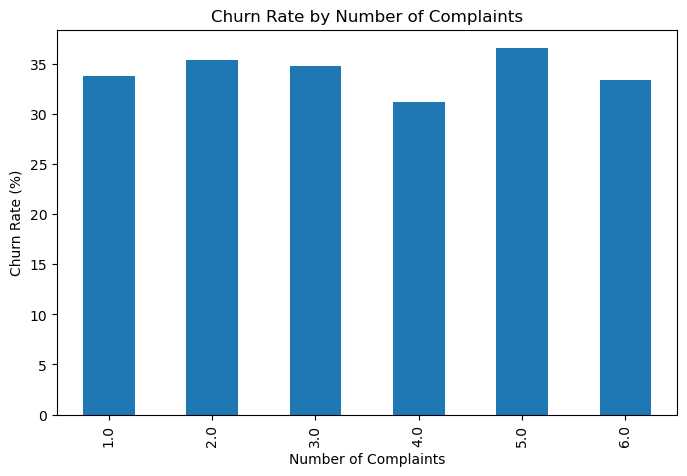

In [110]:
plt.figure(figsize=(8,5))

complaint_churn.plot(kind='bar')

plt.title('Churn Rate by Number of Complaints')
plt.xlabel('Number of Complaints')
plt.ylabel('Churn Rate (%)')
plt.show()

In [111]:
# 4.7 Churn rate by CSAT group

df_visual['csat_group'] = pd.cut(
    df_visual['csat_score'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20', '21-40', '41-60', '61-80', '81-100']
)

csat_churn = (
    df_visual.groupby('csat_group', observed=False)['churn_flag']
      .mean()
      .mul(100)
)

print(csat_churn)

csat_group
0-20      36.218679
21-40     33.709981
41-60     33.503401
61-80     31.454545
81-100    38.610039
Name: churn_flag, dtype: float64


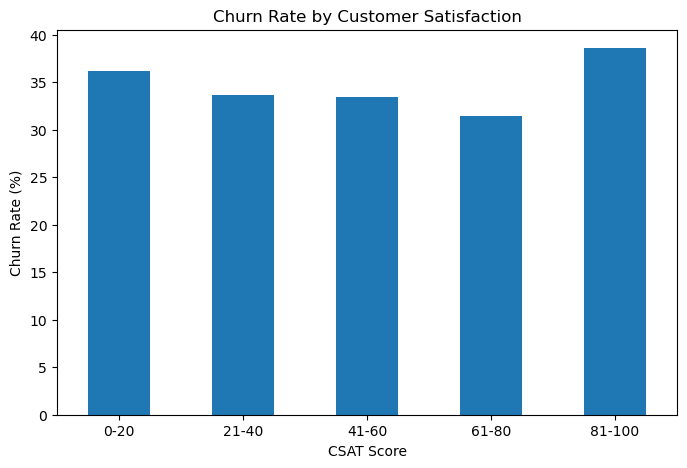

In [112]:
plt.figure(figsize=(8,5))

csat_churn.plot(kind='bar')

plt.title('Churn Rate by Customer Satisfaction')
plt.xlabel('CSAT Score')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [113]:
# 5. Visulaization using Seaborn****************

In [114]:
# Heatmap (Correlation Matrix)

In [115]:
# encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month', 'csat_group'],
      dtype='object')

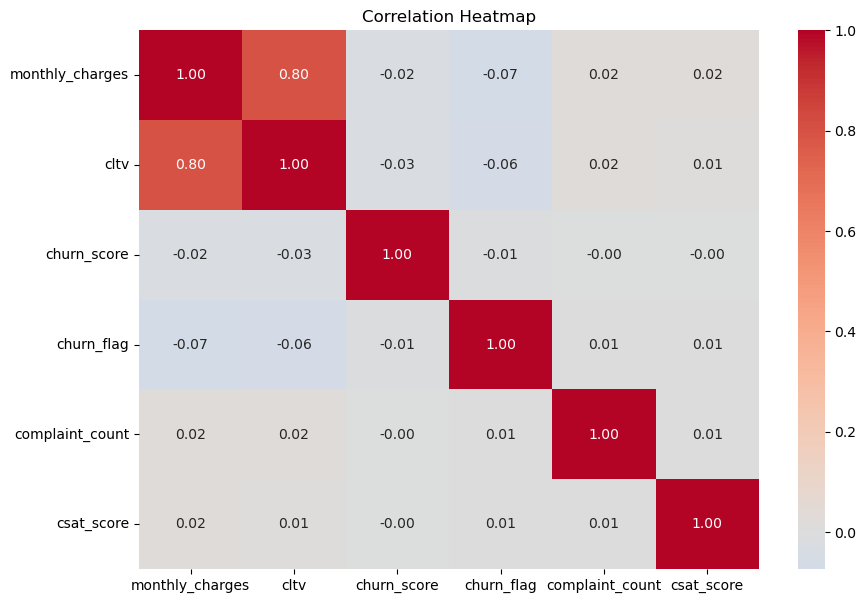

In [116]:
numeric_cols = [
    'monthly_charges',
    'cltv',
    'churn_score',
    'churn_flag',
    'complaint_count',
    'csat_score'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.show()

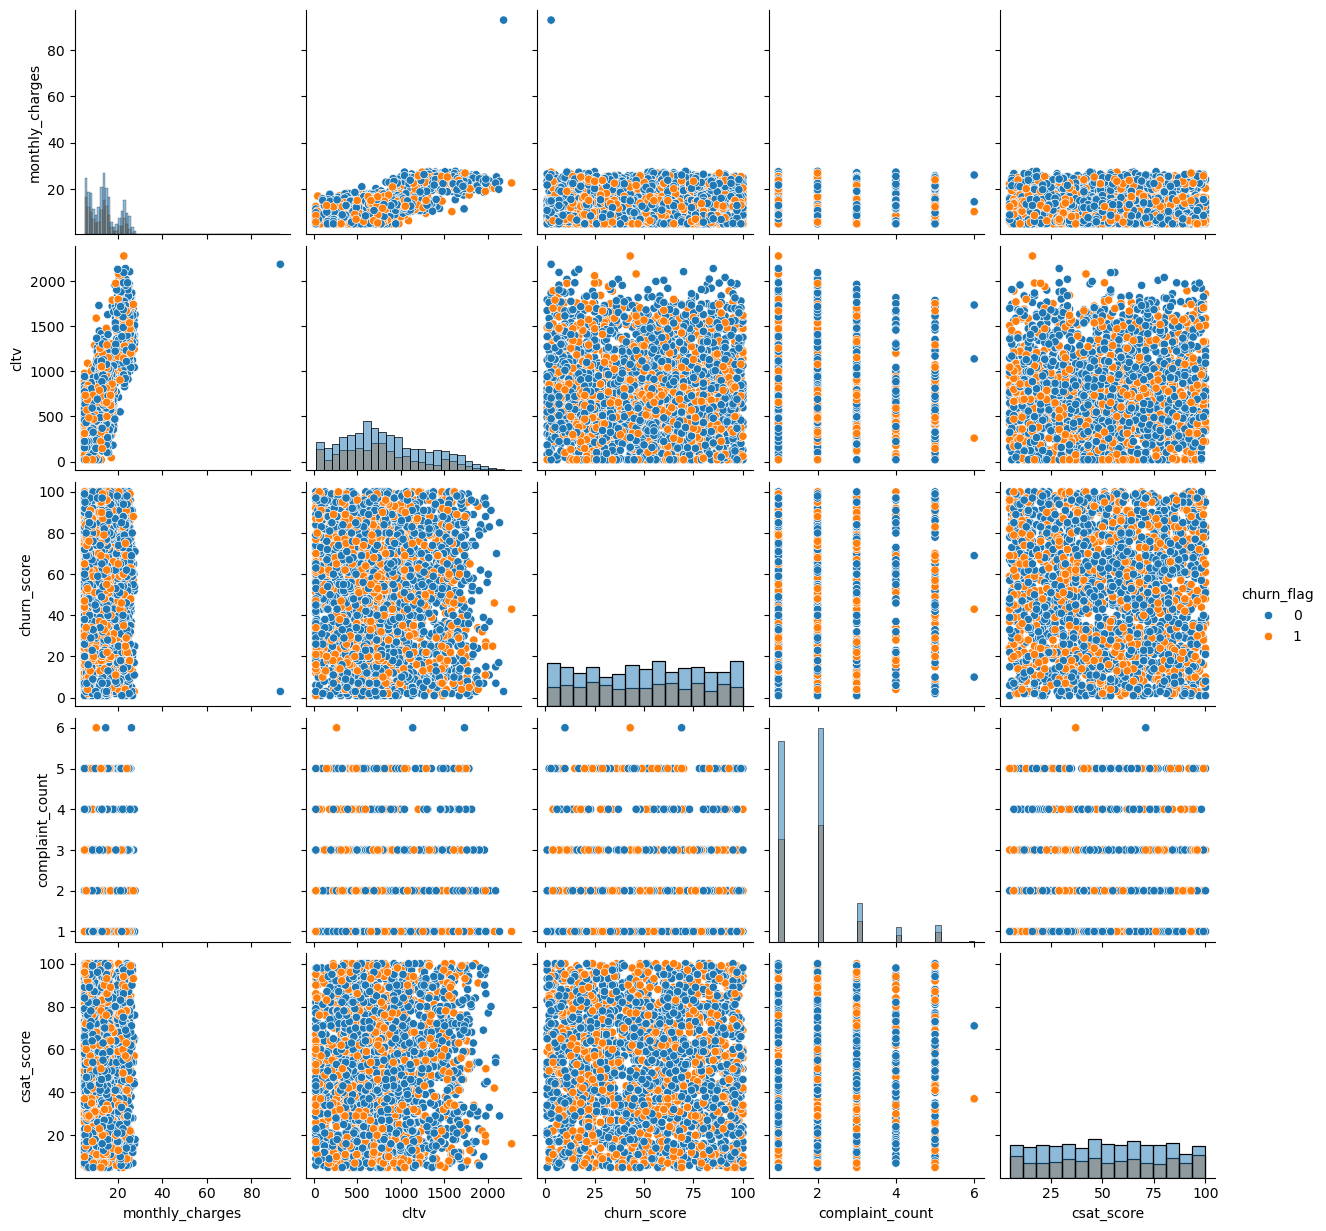

In [117]:
pairplot_cols = [
    'monthly_charges',
    'cltv',
    'churn_score',
    'churn_flag',
    'complaint_count',
    'csat_score'
]

sns.pairplot(
    df[pairplot_cols],
    hue='churn_flag',
    diag_kind='hist'
)

plt.show()

In [118]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month', 'csat_group'],
      dtype='object')

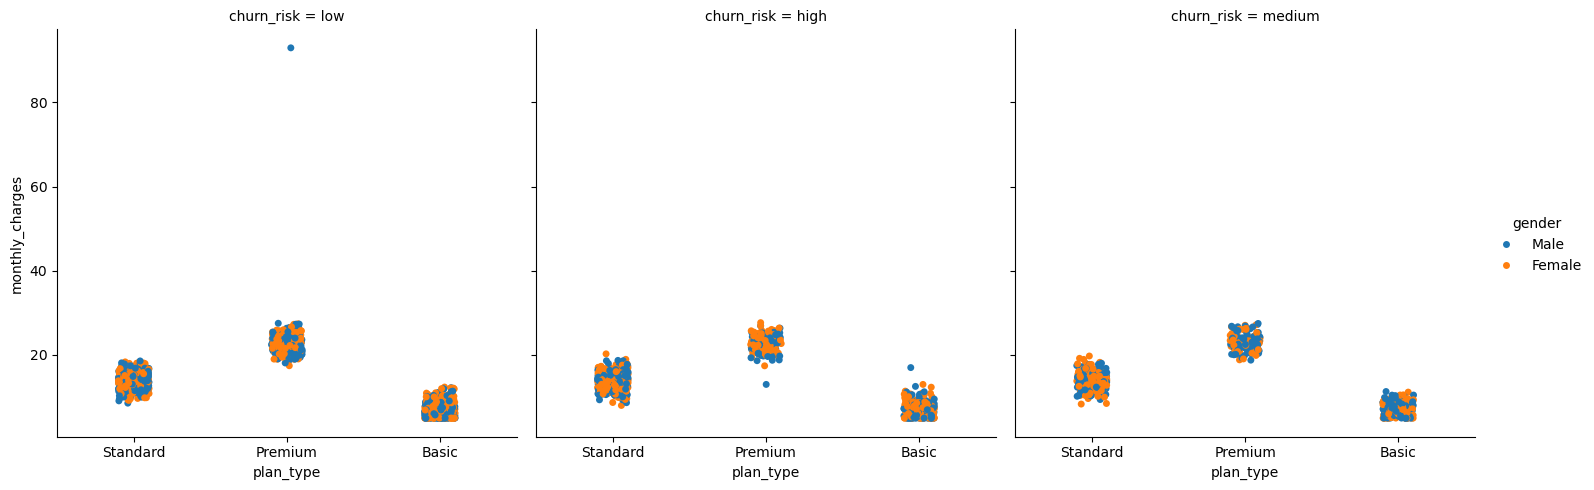

In [119]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

In [120]:
# 6.Pivot table**********

In [121]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc='mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.389831
1,Premium,0.281493
2,Standard,0.343318


In [122]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.389831,1003,7077.07
1,Premium,0.281493,643,14538.23
2,Standard,0.343318,1302,17925.50


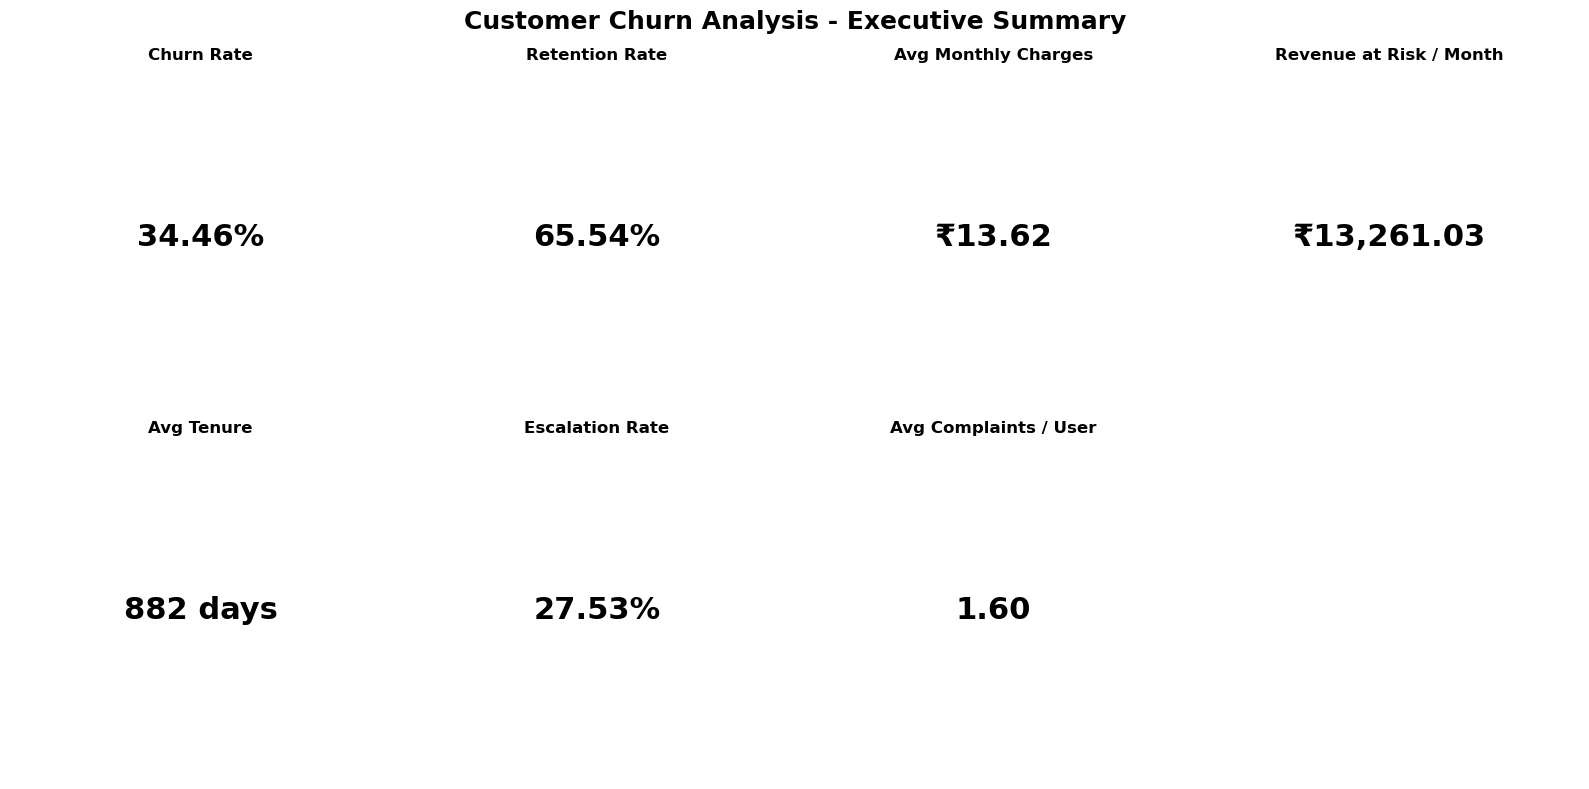

In [123]:
# Executive Summary KPIs

kpis = {
    'Churn Rate': '34.46%',
    'Retention Rate': '65.54%',
    'Avg Monthly Charges': '₹13.62',
    'Revenue at Risk / Month': '₹13,261.03',
    'Avg Tenure': '882 days',
    'Escalation Rate': '27.53%',
    'Avg Complaints / User': '1.60'
}

# Create dashboard
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Convert 2D axes into 1D
axes = axes.flatten()

# Display each KPI
for i, (label, value) in enumerate(kpis.items()):
    axes[i].text(
        0.5,
        0.5,
        value,
        ha='center',
        va='center',
        fontsize=22,
        fontweight='bold'
    )

    axes[i].set_title(
        label,
        fontsize=12,
        fontweight='bold'
    )

    axes[i].axis('off')

# Hide unused box
axes[7].axis('off')

# Main title
plt.suptitle(
    'Customer Churn Analysis - Executive Summary',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()